# Ajuste fino do CodeBERT para detecção de vulnerabilidades
Minicurso de Introdução a LLMs: da teoria dos slides (pré-treinamento → ajuste fino → LoRA) a um caso real de segurança de software.

Tarefa: dada uma função em C, prever se ela contém uma vulnerabilidade. Encoders bidirecionais, como o CodeBERT, costumam ser ajustados para classificação em vez de geração.

![](attachment:finetuning.png)

Dados: Devign [1] (FFmpeg e QEMU), obtido do MADE-WIC [2].

[1] Y. Zhou et al., "Devign: Effective vulnerability identification by learning comprehensive program semantics via graph neural networks", NeurIPS, 2019.
[2] M. Mock et al., "MADE-WIC: Multiple Annotated Datasets for Exploring Weaknesses In Code", ASE, 2024. doi: 10.1145/3691620.3695348.

## 0. Ambiente

In [1]:
%pip install -q peft scikit-learn

In [2]:
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import transformers
import peft
from IPython.display import display, Markdown
from torch.utils.data import DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding,
                          get_linear_schedule_with_warmup, set_seed, utils)
from peft import LoraConfig, TaskType, get_peft_model
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay)

utils.logging.set_verbosity_error()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda"  # precisão mista só na GPU

CORES = {"Classe majoritária": "#8a8984", "TF-IDF + Regressão Logística": "#eda100",
         "Pré-treinado, sem ajuste fino": "#e87ba4", "Ajuste fino completo": "#2a78d6", "LoRA": "#eb6834"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

print(f"transformers {transformers.__version__} | peft {peft.__version__} | torch {torch.__version__} | {DEVICE}"
      + (f" ({torch.cuda.get_device_name()})" if AMP else " (sem GPU: reduza FRACAO e MAX_LEN)"))

transformers 5.16.1 | peft 0.20.0 | torch 2.11.0+cu128 | cuda (Tesla T4)


## 1. Configuração

In [3]:
MODELO = "huggingface/CodeBERTa-small-v1"  # 84M parâmetros; microsoft/codebert-base (125M) com GPU folgada
FRACAO = 0.3                               # fração dos commits usada; 1.0 com GPU e ~1 h disponível
MAX_LEN = 512
MAX_POR_COMMIT = 20                        # commits de refatoração com centenas de funções dominariam o split
BATCH = 16
EPOCAS = 3
LR_COMPLETO = 2e-5                         # ajuste completo: passos pequenos para não apagar o pré-treino
LR_LORA = 5e-4                             # LoRA treina poucas matrizes novas e tolera LR maior
LORA_R, LORA_ALPHA = 8, 16
SEED = 42

set_seed(SEED)

## 2. Dados: Devign

In [4]:
if not Path("devign/complete.csv").exists():
    !wget -q -O MADE-WIC.zip "https://zenodo.org/records/13370805/files/MADE-WIC.zip?download=1"
    !unzip -qj MADE-WIC.zip "MADE-WIC/Dataset/devign/*" -d devign
    !rm MADE-WIC.zip

bruto = pd.read_csv("devign/complete.csv", usecols=["Projectname", "Commit-ID", "Function", "Devign"])
bruto.columns = ["projeto", "commit", "codigo", "rotulo"]

# mesma função com rótulos opostos: ruído, não informação
conflito = bruto["codigo"].duplicated(keep=False)
df = bruto[~conflito]
df = df.sample(frac=1, random_state=SEED).groupby("commit").head(MAX_POR_COMMIT).reset_index(drop=True)
print(f"{len(bruto):,} funções | {conflito.sum()} removidas por rótulo conflitante | "
      f"{len(bruto) - conflito.sum() - len(df):,} cortadas pelo limite por commit | {len(df):,} restantes")

resumo = df.groupby("projeto").agg(funcoes=("rotulo", "size"), commits=("commit", "nunique"),
                                   vulneraveis=("rotulo", "mean"))
display(resumo.style.format({"funcoes": "{:,}", "commits": "{:,}", "vulneraveis": "{:.1%}"}))

27,282 funções | 92 removidas por rótulo conflitante | 2,837 cortadas pelo limite por commit | 24,353 restantes


,funcoes,commits,vulneraveis
projeto,,,
FFmpeg,"9,311","5,894",51.1%
qemu,"15,042","6,376",45.3%


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/994k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/483k [00:00<?, ?B/s]

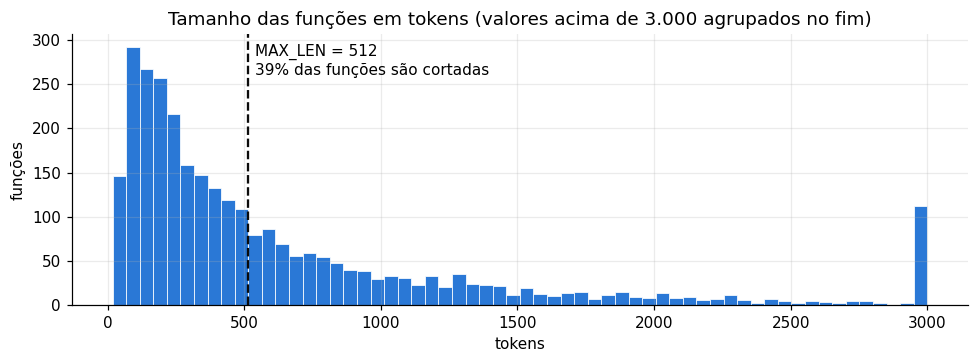

mediana: 370 tokens | p90: 1630


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODELO)

amostra = df["codigo"].sample(3000, random_state=SEED)
n_tokens = np.array([len(ids) for ids in tokenizer(amostra.tolist())["input_ids"]])
truncadas = (n_tokens > MAX_LEN).mean()

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(np.clip(n_tokens, 0, 3000), bins=60, color="#2a78d6", edgecolor="white", linewidth=0.5)
ax.axvline(MAX_LEN, color="#0b0b0b", ls="--", lw=1.5)
ax.text(MAX_LEN * 1.05, ax.get_ylim()[1] * 0.85, f"MAX_LEN = {MAX_LEN}\n{truncadas:.0%} das funções são cortadas")
ax.set(title="Tamanho das funções em tokens (valores acima de 3.000 agrupados no fim)", xlabel="tokens", ylabel="funções")
plt.tight_layout(); plt.show()
print(f"mediana: {np.median(n_tokens):.0f} tokens | p90: {np.percentile(n_tokens, 90):.0f}")

### Armadilha: vazamento entre commits

12,270 commits | funções por commit: mediana 1, máx 20 | commits com rótulos mistos: 0


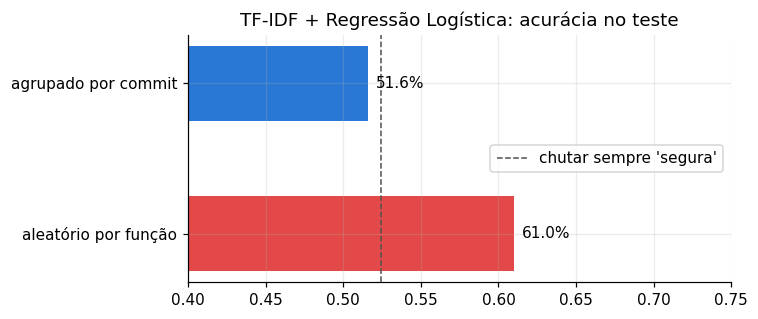

In [6]:
por_commit = df.groupby("commit").agg(n=("rotulo", "size"), rotulos=("rotulo", "nunique"))
print(f"{len(por_commit):,} commits | funções por commit: mediana {por_commit['n'].median():.0f}, máx {por_commit['n'].max()}"
      f" | commits com rótulos mistos: {(por_commit['rotulos'] > 1).sum()}")


def tfidf_lr(treino, teste):
    # hashing em vez de vocabulário explícito: memória fixa mesmo com bigramas
    vet = make_pipeline(HashingVectorizer(token_pattern=r"[A-Za-z_]\w*|\S", ngram_range=(1, 2), n_features=2**18,
                                          alternate_sign=False, norm=None),
                        TfidfTransformer(sublinear_tf=True))
    clf = LogisticRegression(max_iter=2000).fit(vet.fit_transform(treino["codigo"]), treino["rotulo"])
    return clf.predict_proba(vet.transform(teste["codigo"]))[:, 1]


# mesmo modelo, duas formas de separar treino e teste
tr, te = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["rotulo"])
i_tr, i_te = next(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
                  .split(df, df["rotulo"], groups=df["commit"]))
vazamento = pd.Series({
    "aleatório por função": accuracy_score(te["rotulo"], tfidf_lr(tr, te) >= 0.5),
    "agrupado por commit": accuracy_score(df["rotulo"].iloc[i_te], tfidf_lr(df.iloc[i_tr], df.iloc[i_te]) >= 0.5),
})

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(vazamento.index, vazamento.values, color=["#e34948", "#2a78d6"], height=0.5)
ax.axvline(1 - df["rotulo"].mean(), color="#52514e", ls="--", lw=1, label="chutar sempre 'segura'")
for i, v in enumerate(vazamento.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center")
ax.set(title="TF-IDF + Regressão Logística: acurácia no teste", xlim=(0.4, 0.75))
ax.legend(loc="center right"); plt.tight_layout(); plt.show()

In [7]:
# split 80/10/10 estratificado e sem commits compartilhados
commits = df["commit"].drop_duplicates().sample(frac=FRACAO, random_state=SEED)
dados = df[df["commit"].isin(commits)].reset_index(drop=True)

folds = list(StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
             .split(dados, dados["rotulo"], groups=dados["commit"]))
i_teste, i_val = folds[0][1], folds[1][1]
i_treino = np.setdiff1d(np.arange(len(dados)), np.concatenate([i_teste, i_val]))
treino, val, teste = (dados.iloc[i].reset_index(drop=True) for i in (i_treino, i_val, i_teste))

assert not set(treino["commit"]) & (set(val["commit"]) | set(teste["commit"]))
display(pd.DataFrame({nome: {"funções": len(p), "commits": p["commit"].nunique(), "vulneráveis": p["rotulo"].mean()}
                      for nome, p in [("treino", treino), ("validação", val), ("teste", teste)]}).T
        .style.format({"funções": "{:,.0f}", "commits": "{:,.0f}", "vulneráveis": "{:.1%}"}))

,funções,commits,vulneráveis
treino,"5,885","2,945",48.0%
validação,703,368,48.5%
teste,753,368,54.2%


In [8]:
def carregador(parte, embaralhar=False):
    enc = tokenizer(parte["codigo"].tolist(), truncation=True, max_length=MAX_LEN)
    itens = [{"input_ids": i, "attention_mask": m, "labels": int(y)}
             for i, m, y in zip(enc["input_ids"], enc["attention_mask"], parte["rotulo"])]
    # padding dinâmico: cada lote só é completado até a maior função dele
    return DataLoader(itens, batch_size=BATCH, shuffle=embaralhar, collate_fn=DataCollatorWithPadding(tokenizer))


dl_treino, dl_val, dl_teste = carregador(treino, embaralhar=True), carregador(val), carregador(teste)
y_val, y_teste = val["rotulo"].to_numpy(), teste["rotulo"].to_numpy()

## 3. Linhas de base

In [9]:
def auc(y, p):
    return roc_auc_score(y, p) if len(set(y)) == 2 else np.nan


def metricas(y, p, limiar=0.5):
    pred = p >= limiar
    return {"acurácia": accuracy_score(y, pred), "precisão": precision_score(y, pred, zero_division=0),
            "revocação": recall_score(y, pred, zero_division=0), "F1": f1_score(y, pred, zero_division=0),
            "ROC-AUC": auc(y, p)}


@torch.no_grad()
def prever(modelo, dl):
    modelo.eval()
    saida = []
    for lote in dl:
        lote = {k: v.to(DEVICE) for k, v in lote.items()}
        with torch.autocast(DEVICE, dtype=torch.float16, enabled=AMP):
            logits = modelo(**lote).logits
        saida.append(logits.float().softmax(-1)[:, 1].cpu())
    return torch.cat(saida).numpy()


def novo_modelo():
    set_seed(SEED)
    return AutoModelForSequenceClassification.from_pretrained(MODELO, num_labels=2)


probs = {
    "Classe majoritária": np.full(len(teste), float(treino["rotulo"].mean() >= 0.5)),
    "TF-IDF + Regressão Logística": tfidf_lr(treino, teste),
}

# encoder pré-treinado + cabeça de classificação aleatória, antes de qualquer ajuste
modelo_completo = novo_modelo().to(DEVICE)
probs["Pré-treinado, sem ajuste fino"] = prever(modelo_completo, dl_teste)

display(pd.DataFrame({n: metricas(y_teste, p) for n, p in probs.items()}).T.style.format("{:.3f}"))

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  336MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  336MB            

model.safetensors: downloading bytes:           |  0.00B            

,acurácia,precisão,revocação,F1,ROC-AUC
Classe majoritária,0.458,0.000,0.000,0.000,0.500
TF-IDF + Regressão Logística,0.459,0.501,0.463,0.482,0.451
"Pré-treinado, sem ajuste fino",0.458,0.500,0.054,0.097,0.455


## 4. A perda: a mesma entropia cruzada do pré-treinamento
Nos slides: $L_{CE} = -\sum_{w \in V} y_t[w] \log \hat{y}_t[w] = -\log \hat{y}_t[w_{t+1}]$.
No ajuste fino, o "vocabulário" encolhe para duas classes, $V = \{\text{segura}, \text{vulnerável}\}$, e a perda é $-\log \hat{y}[\text{classe correta}]$.

In [10]:
lote = {k: v.to(DEVICE) for k, v in next(iter(dl_val)).items()}
modelo_completo.eval()
with torch.no_grad():
    saida = modelo_completo(**lote)
logits, y = saida.logits.float(), lote["labels"]
p = logits.softmax(-1)
manual = -torch.log(p[torch.arange(len(y)), y])

display(pd.DataFrame({"P(segura)": p[:, 0].cpu(), "P(vulnerável)": p[:, 1].cpu(), "rótulo": y.cpu(),
                      "-log P(correta)": manual.cpu()}).head(6).style.format(precision=3))
print(f"média manual: {manual.mean():.4f} | F.cross_entropy: {F.cross_entropy(logits, y):.4f} | "
      f"perda do modelo: {saida.loss.float():.4f}")

,P(segura),P(vulnerável),rótulo,-log P(correta)
0,0.544,0.456,1,0.785
1,0.528,0.472,1,0.750
2,0.556,0.444,1,0.813
3,0.548,0.452,1,0.794
4,0.545,0.455,1,0.788
5,0.565,0.435,1,0.833


média manual: 0.7445 | F.cross_entropy: 0.7445 | perda do modelo: 0.7445


## 5. Ajuste fino completo: todos os parâmetros são atualizados

In [11]:
def parametros(modelo):
    return sum(p.numel() for p in modelo.parameters()), sum(p.numel() for p in modelo.parameters() if p.requires_grad)


def tamanho_mb(modelo, pasta):
    shutil.rmtree(pasta, ignore_errors=True)
    modelo.save_pretrained(pasta)
    return sum(f.stat().st_size for f in Path(pasta).rglob("*") if f.is_file()) / 2**20


def treinar(modelo, lr, nome):
    otimizador = torch.optim.AdamW([p for p in modelo.parameters() if p.requires_grad], lr=lr, weight_decay=0.01)
    passos = EPOCAS * len(dl_treino)
    agenda = get_linear_schedule_with_warmup(otimizador, int(0.1 * passos), passos)
    escala = torch.amp.GradScaler("cuda", enabled=AMP)
    historico, perdas, melhor, inicio = [], [], (-1.0, None), time.time()

    for epoca in range(1, EPOCAS + 1):
        modelo.train()
        for lote in dl_treino:
            lote = {k: v.to(DEVICE) for k, v in lote.items()}
            with torch.autocast(DEVICE, dtype=torch.float16, enabled=AMP):
                perda = modelo(**lote).loss                     # entropia cruzada
            escala.scale(perda).backward()                      # retropropagação
            escala.unscale_(otimizador)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            escala.step(otimizador)                             # descida do gradiente
            escala.update(); otimizador.zero_grad(); agenda.step()
            perdas.append(perda.item())

        p_val = prever(modelo, dl_val)
        historico.append({"época": epoca, "F1 val": f1_score(y_val, p_val >= 0.5), "AUC val": roc_auc_score(y_val, p_val)})
        print(f"[{nome}] época {epoca}/{EPOCAS} | perda {np.mean(perdas[-len(dl_treino):]):.4f} | "
              f"F1 val {historico[-1]['F1 val']:.3f} | AUC val {historico[-1]['AUC val']:.3f} | {time.time() - inicio:.0f}s")
        if historico[-1]["AUC val"] > melhor[0]:              # guarda a melhor época na validação
            melhor = (historico[-1]["AUC val"], {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()})

    modelo.load_state_dict(melhor[1])
    return {"historico": pd.DataFrame(historico), "perdas": perdas, "tempo": time.time() - inicio}


treinos, custos, probs_val = {}, {}, {}
treinos["Ajuste fino completo"] = treinar(modelo_completo, LR_COMPLETO, "completo")
probs["Ajuste fino completo"] = prever(modelo_completo, dl_teste)
probs_val["Ajuste fino completo"] = prever(modelo_completo, dl_val)
custos["Ajuste fino completo"] = (*parametros(modelo_completo), treinos["Ajuste fino completo"]["tempo"],
                                  tamanho_mb(modelo_completo, "saida/completo"))

[completo] época 1/3 | perda 0.6918 | F1 val 0.147 | AUC val 0.599 | 87s
[completo] época 2/3 | perda 0.6099 | F1 val 0.564 | AUC val 0.585 | 179s
[completo] época 3/3 | perda 0.4744 | F1 val 0.529 | AUC val 0.600 | 272s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 6. LoRA: congelar $W$ e treinar uma atualização de baixo posto
Nos slides: substituímos $W + \Delta W$ por $W + BA$, e a passagem direta vira $h = xW + xAB$, com $A \in \mathbb{R}^{d \times r}$, $B \in \mathbb{R}^{r \times k}$ e $r$ pequeno.

![](attachment:lora.png)

In [14]:
%pip uninstall -q -y torchao

In [15]:
config_lora = LoraConfig(task_type=TaskType.SEQ_CLS, r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=0.1,
                         target_modules=["query", "value"])     # W_Q e W_V de todas as camadas de atenção
modelo_lora = get_peft_model(novo_modelo(), config_lora).to(DEVICE)
modelo_lora.print_trainable_parameters()

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

trainable params: 739,586 || all params: 84,192,004 || trainable%: 0.8785


In [17]:
# conferindo h = xW + xAB em uma camada real
camada = modelo_lora.base_model.model.roberta.encoder.layer[0].attention.self.query
W, b = camada.base_layer.weight, camada.base_layer.bias                    # congelados
A, B = camada.lora_A["default"].weight, camada.lora_B["default"].weight    # treináveis
escala = camada.scaling["default"]                                         # alpha / r
print(f"W: {tuple(W.T.shape)} = {W.numel():,} parâmetros | A: {tuple(A.T.shape)} + B: {tuple(B.T.shape)} = "
      f"{A.numel() + B.numel():,} ({(A.numel() + B.numel()) / W.numel():.1%} de W)")
print(f"B começa zerada ({B.abs().max().item():.0f}), então o modelo inicial é idêntico ao pré-treinado")

modelo_lora.eval()
with torch.no_grad():
    torch.nn.init.normal_(B, std=0.02)                                     # perturbação só para o teste
    x = torch.randn(4, W.shape[1], device=DEVICE)
    h_manual = x @ W.T + b + escala * (x @ A.T @ B.T)
    print("h = xW + xAB confere com a camada?", torch.allclose(camada(x), h_manual, atol=1e-5))
    torch.nn.init.zeros_(B)

W: (768, 768) = 589,824 parâmetros | A: (768, 8) + B: (8, 768) = 12,288 (2.1% de W)
B começa zerada (0), então o modelo inicial é idêntico ao pré-treinado
h = xW + xAB confere com a camada? True


In [18]:
treinos["LoRA"] = treinar(modelo_lora, LR_LORA, "LoRA")
probs["LoRA"] = prever(modelo_lora, dl_teste)
probs_val["LoRA"] = prever(modelo_lora, dl_val)
custos["LoRA"] = (*parametros(modelo_lora), treinos["LoRA"]["tempo"], tamanho_mb(modelo_lora, "saida/lora"))

[LoRA] época 1/3 | perda 0.7186 | F1 val 0.029 | AUC val 0.547 | 87s
[LoRA] época 2/3 | perda 0.6785 | F1 val 0.321 | AUC val 0.578 | 160s
[LoRA] época 3/3 | perda 0.6390 | F1 val 0.525 | AUC val 0.581 | 235s


## 7. Avaliação no teste

In [19]:
tabela = pd.DataFrame({n: metricas(y_teste, p) for n, p in probs.items()}).T.join(
    pd.DataFrame(custos, index=["parâmetros", "treináveis", "tempo (s)", "disco (MB)"]).T)
tabela["% treinável"] = tabela["treináveis"] / tabela["parâmetros"]

display(tabela.style.format({**{c: "{:.3f}" for c in ["acurácia", "precisão", "revocação", "F1", "ROC-AUC"]},
                             "parâmetros": "{:,.0f}", "treináveis": "{:,.0f}", "tempo (s)": "{:.0f}",
                             "disco (MB)": "{:.1f}", "% treinável": "{:.2%}"}, na_rep="—")
        .highlight_max(subset=["F1", "ROC-AUC"], color="#cde2fb"))

,acurácia,precisão,revocação,F1,ROC-AUC,parâmetros,treináveis,tempo (s),disco (MB),% treinável
Classe majoritária,0.458,0.000,0.000,0.000,0.500,—,—,—,—,—
TF-IDF + Regressão Logística,0.459,0.501,0.463,0.482,0.451,—,—,—,—,—
"Pré-treinado, sem ajuste fino",0.458,0.500,0.054,0.097,0.455,—,—,—,—,—
Ajuste fino completo,0.505,0.556,0.426,0.483,0.516,"83,452,418","83,452,418",272,318.4,100.00%
LoRA,0.470,0.514,0.402,0.451,0.490,"84,192,004","739,586",235,2.8,0.88%


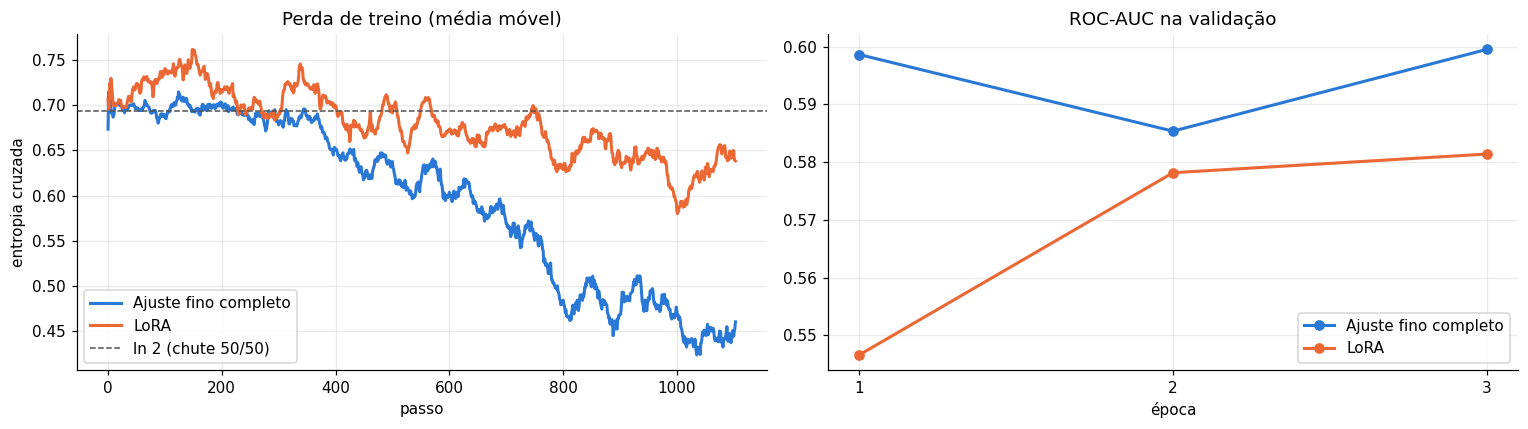

In [20]:
ajustados = ["Ajuste fino completo", "LoRA"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for nome in ajustados:
    perdas = pd.Series(treinos[nome]["perdas"])
    axes[0].plot(perdas.rolling(max(1, len(perdas) // 30), min_periods=1).mean(), color=CORES[nome], lw=2, label=nome)
    h = treinos[nome]["historico"]
    axes[1].plot(h["época"], h["AUC val"], marker="o", color=CORES[nome], lw=2, label=nome)
axes[0].axhline(np.log(2), color="#52514e", ls="--", lw=1, label="ln 2 (chute 50/50)")
axes[0].set(title="Perda de treino (média móvel)", xlabel="passo", ylabel="entropia cruzada")
axes[1].set(title="ROC-AUC na validação", xlabel="época", xticks=range(1, EPOCAS + 1))
for ax in axes:
    ax.legend()
plt.tight_layout(); plt.show()

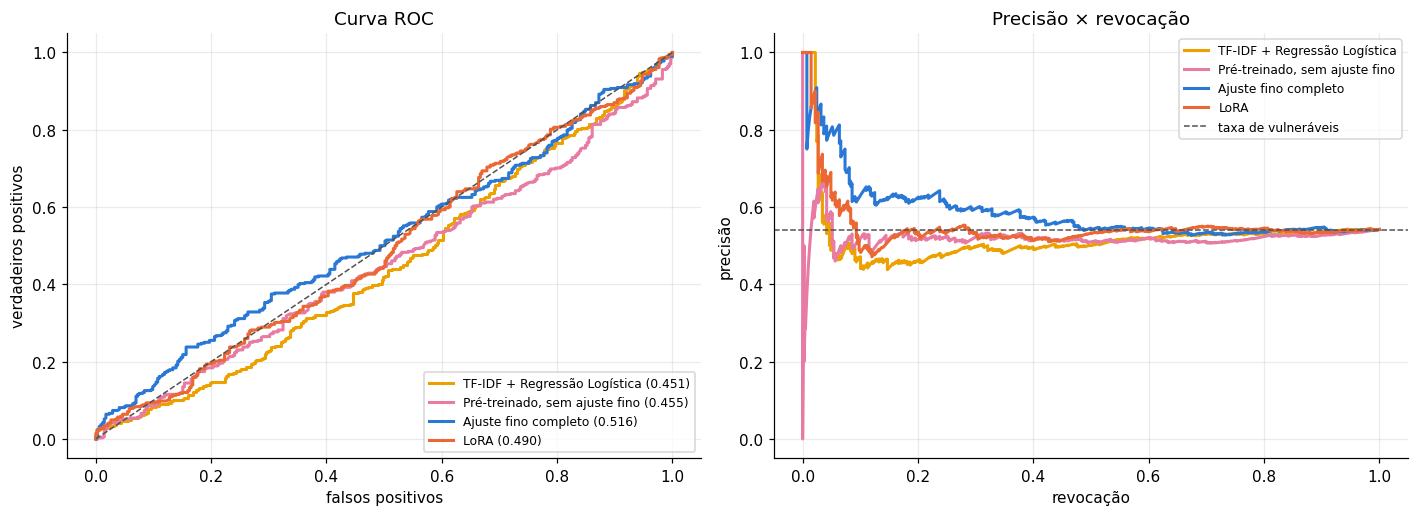

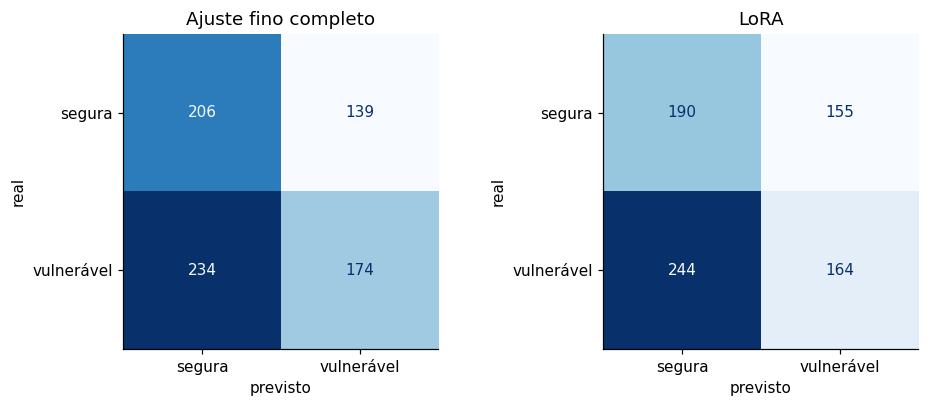

In [21]:
comparados = ["TF-IDF + Regressão Logística", "Pré-treinado, sem ajuste fino"] + ajustados
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for nome in comparados:
    fpr, tpr, _ = roc_curve(y_teste, probs[nome])
    prec, rev, _ = precision_recall_curve(y_teste, probs[nome])
    auc_nome = tabela.loc[nome, "ROC-AUC"]
    axes[0].plot(fpr, tpr, color=CORES[nome], lw=2, label=f"{nome} ({auc_nome:.3f})")
    axes[1].plot(rev, prec, color=CORES[nome], lw=2, label=nome)
axes[0].plot([0, 1], [0, 1], color="#52514e", ls="--", lw=1)
axes[1].axhline(y_teste.mean(), color="#52514e", ls="--", lw=1, label="taxa de vulneráveis")
axes[0].set(title="Curva ROC", xlabel="falsos positivos", ylabel="verdadeiros positivos")
axes[1].set(title="Precisão × revocação", xlabel="revocação", ylabel="precisão")
axes[0].legend(fontsize=8, loc="lower right"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, nome in zip(axes, ajustados):
    ConfusionMatrixDisplay(confusion_matrix(y_teste, probs[nome] >= 0.5),
                           display_labels=["segura", "vulnerável"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set(title=nome, xlabel="previsto", ylabel="real"); ax.grid(False)
plt.tight_layout(); plt.show()

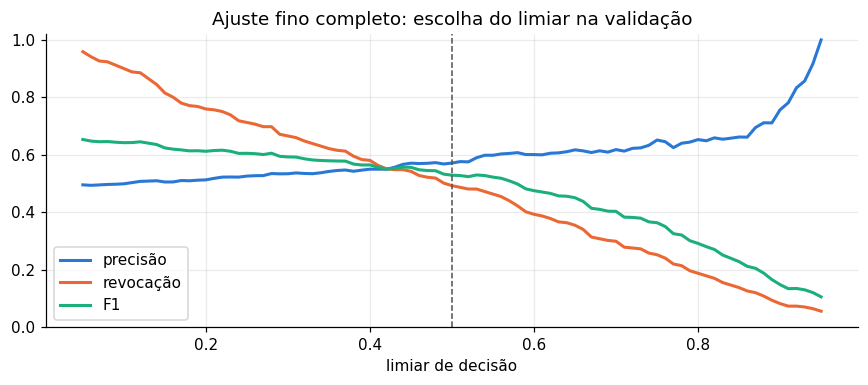

limiar de maior F1 na validação: 0.05 -> no teste: F1 0.683 (com 0.5: 0.483)


In [22]:
# limiar: 0,5 não é obrigatório; o custo de um alarme falso x uma falha não detectada define o ponto
melhor = max(ajustados, key=lambda n: roc_auc_score(y_val, probs_val[n]))
limiares = np.linspace(0.05, 0.95, 91)
curvas = pd.DataFrame([{"limiar": t, **metricas(y_val, probs_val[melhor], t)} for t in limiares]).set_index("limiar")

ax = curvas[["precisão", "revocação", "F1"]].plot(figsize=(8, 3.6), lw=2, color=["#2a78d6", "#eb6834", "#1baf7a"])
ax.axvline(0.5, color="#52514e", ls="--", lw=1)
ax.set(title=f"{melhor}: escolha do limiar na validação", xlabel="limiar de decisão", ylim=(0, 1.02))
plt.tight_layout(); plt.show()
t_f1 = curvas["F1"].idxmax()
print(f"limiar de maior F1 na validação: {t_f1:.2f} -> no teste: F1 {metricas(y_teste, probs[melhor], t_f1)['F1']:.3f} "
      f"(com 0.5: {tabela.loc[melhor, 'F1']:.3f})")

In [23]:
# onde o modelo acerta e erra: por projeto e por truncamento
teste["tokens"] = [len(i) for i in tokenizer(teste["codigo"].tolist())["input_ids"]]
teste["faixa"] = np.where(teste["tokens"] > MAX_LEN, f"> {MAX_LEN} tokens (cortada)", f"≤ {MAX_LEN} tokens")
recortes = []
for coluna in ["projeto", "faixa"]:
    for valor, grupo in teste.groupby(coluna):
        idx = grupo.index.to_numpy()
        recortes.append({"recorte": coluna, "grupo": valor, "funções": len(idx), "vulneráveis": y_teste[idx].mean(),
                         **{f"AUC {n}": auc(y_teste[idx], probs[n][idx]) for n in ["TF-IDF + Regressão Logística"] + ajustados}})
recortes = pd.DataFrame(recortes).set_index(["recorte", "grupo"])
display(recortes.style.format({"vulneráveis": "{:.1%}", **{c: "{:.3f}" for c in recortes.columns if c.startswith("AUC")}},
                              na_rep="—"))

## 8. Testando com código escrito na hora

In [24]:
exemplos = {
    "strcpy sem limite": '''void copia(char *entrada) {
    char buf[16];
    strcpy(buf, entrada);
    printf("%s", buf);
}''',
    "strncpy com limite": '''void copia(char *entrada) {
    char buf[16];
    strncpy(buf, entrada, sizeof(buf) - 1);
    buf[sizeof(buf) - 1] = '\\0';
    printf("%s", buf);
}''',
    "índice sem checagem": '''int le(int *v, int n, int i) {
    return v[i];
}''',
    "índice com checagem": '''int le(int *v, int n, int i) {
    if (i < 0 || i >= n)
        return -1;
    return v[i];
}''',
}

dl_ex = carregador(pd.DataFrame({"codigo": list(exemplos.values()), "rotulo": 0}))
display(pd.DataFrame({n: prever(m, dl_ex) for n, m in [("Ajuste fino completo", modelo_completo), ("LoRA", modelo_lora)]},
                     index=list(exemplos)).style.format("{:.1%}").set_caption("P(vulnerável)"))

,Ajuste fino completo,LoRA
strcpy sem limite,95.6%,79.9%
strncpy com limite,96.9%,91.9%
índice sem checagem,56.3%,57.8%
índice com checagem,85.9%,75.0%


## Achados

In [25]:
t = tabela
c, l, tf, sa = (t.loc[n] for n in ["Ajuste fino completo", "LoRA", "TF-IDF + Regressão Logística", "Pré-treinado, sem ajuste fino"])
melhor_auc = "LoRA" if l["ROC-AUC"] >= c["ROC-AUC"] else "Ajuste fino completo"
ex = pd.DataFrame({n: prever(m, dl_ex) for n, m in [("c", modelo_completo), ("l", modelo_lora)]}, index=list(exemplos))
separa = ((ex.loc["strcpy sem limite"] > ex.loc["strncpy com limite"]) & (ex.loc["índice sem checagem"] > ex.loc["índice com checagem"])).sum()
faixas = recortes.xs("faixa").iloc[:, -2:].mean(axis=1)  # AUC médio dos dois modelos ajustados
auc_cortada, auc_inteira = faixas[faixas.index.str.startswith(">")].mean(), faixas[~faixas.index.str.startswith(">")].mean()

achados = [
    f"**Vazamento infla o resultado.** Com split aleatório por função, o TF-IDF atinge {vazamento['aleatório por função']:.1%} de acurácia; "
    f"separando por commit, cai para {vazamento['agrupado por commit']:.1%}. Todas as funções de um commit têm o mesmo rótulo, "
    f"então o split aleatório premia quem memoriza o commit, não quem entende a vulnerabilidade. Usamos o split agrupado.",
    f"**O pré-treino sozinho não resolve a tarefa.** Sem ajuste fino, a cabeça aleatória fica em ROC-AUC {sa['ROC-AUC']:.3f} (acaso = 0.5). "
    f"Depois do ajuste, o completo chega a {c['ROC-AUC']:.3f} e o LoRA a {l['ROC-AUC']:.3f}.",
    f"**LoRA treina {l['% treinável']:.2%} dos parâmetros** ({l['treináveis']:,.0f} de {l['parâmetros']:,.0f}) e salva "
    f"{l['disco (MB)']:.1f} MB contra {c['disco (MB)']:.1f} MB do ajuste completo ({c['disco (MB)'] / l['disco (MB)']:.0f}x menor). "
    f"O tempo de treino foi {l['tempo (s)']:.0f}s contra {c['tempo (s)']:.0f}s: o forward continua passando pelo modelo inteiro, "
    f"e a economia principal está na memória do otimizador e no armazenamento. Na qualidade, a diferença de F1 foi "
    f"{l['F1'] - c['F1']:+.3f} e a de ROC-AUC {l['ROC-AUC'] - c['ROC-AUC']:+.3f} (LoRA − completo).",
    f"**Contra a linha de base clássica:** o TF-IDF faz ROC-AUC {tf['ROC-AUC']:.3f} no mesmo split, e o melhor ajustado "
    f"({melhor_auc}) faz {t.loc[melhor_auc, 'ROC-AUC']:.3f} ({t.loc[melhor_auc, 'ROC-AUC'] - tf['ROC-AUC']:+.3f}). "
    + ("Em segurança de código, alguns centésimos de AUC já justificam o transformer, mas a linha de base deve estar sempre no slide."
       if t.loc[melhor_auc, "ROC-AUC"] > tf["ROC-AUC"]
       else "Aqui o transformer não superou o modelo clássico: com poucos dados e épocas, o custo extra não se pagou."),
    f"**O Devign é difícil.** O CodeXGLUE reporta cerca de 62% de acurácia para o CodeBERT neste dataset. Os rótulos vêm de "
    f"commits de correção, que são ruidosos, e {truncadas:.0%} das funções passam de {MAX_LEN} tokens e são cortadas "
    f"(ROC-AUC médio dos modelos ajustados: {auc_inteira:.3f} nas funções inteiras x {auc_cortada:.3f} nas cortadas).",
    f"**Teste de sanidade com código novo:** em {separa} de 4 comparações (2 pares × 2 modelos), a versão insegura recebeu "
    f"probabilidade maior que a corrigida"
    + (", mas com diferenças pequenas: o modelo capta pistas superficiais (strcpy, ausência de if), não prova ausência de estouro."
       if separa >= 3 else
       ". O modelo aprendeu padrões estatísticos do FFmpeg/QEMU, não o conceito de estouro de buffer: não é um verificador."),
    "**Próximos passos:** FRACAO = 1.0, `microsoft/codebert-base` ou `unixcoder`, janelas deslizantes para funções longas, "
    "LoRA também em W_K, W_O e FFN, e escolher o limiar pelo custo real de alarmes falsos.",
]
display(Markdown("\n".join(f"- {a}" for a in achados)))

- **Vazamento infla o resultado.** Com split aleatório por função, o TF-IDF atinge 61.0% de acurácia; separando por commit, cai para 51.6%. Todas as funções de um commit têm o mesmo rótulo, então o split aleatório premia quem memoriza o commit, não quem entende a vulnerabilidade. Usamos o split agrupado.
- **O pré-treino sozinho não resolve a tarefa.** Sem ajuste fino, a cabeça aleatória fica em ROC-AUC 0.455 (acaso = 0.5). Depois do ajuste, o completo chega a 0.516 e o LoRA a 0.490.
- **LoRA treina 0.88% dos parâmetros** (739,586 de 84,192,004) e salva 2.8 MB contra 318.4 MB do ajuste completo (112x menor). O tempo de treino foi 235s contra 272s: o forward continua passando pelo modelo inteiro, e a economia principal está na memória do otimizador e no armazenamento. Na qualidade, a diferença de F1 foi -0.031 e a de ROC-AUC -0.026 (LoRA − completo).
- **Contra a linha de base clássica:** o TF-IDF faz ROC-AUC 0.451 no mesmo split, e o melhor ajustado (Ajuste fino completo) faz 0.516 (+0.065). Em segurança de código, alguns centésimos de AUC já justificam o transformer, mas a linha de base deve estar sempre no slide.
- **O Devign é difícil.** O CodeXGLUE reporta cerca de 62% de acurácia para o CodeBERT neste dataset. Os rótulos vêm de commits de correção, que são ruidosos, e 39% das funções passam de 512 tokens e são cortadas (ROC-AUC médio dos modelos ajustados: 0.516 nas funções inteiras x 0.491 nas cortadas).
- **Teste de sanidade com código novo:** em 0 de 4 comparações (2 pares × 2 modelos), a versão insegura recebeu probabilidade maior que a corrigida. O modelo aprendeu padrões estatísticos do FFmpeg/QEMU, não o conceito de estouro de buffer: não é um verificador.
- **Próximos passos:** FRACAO = 1.0, `microsoft/codebert-base` ou `unixcoder`, janelas deslizantes para funções longas, LoRA também em W_K, W_O e FFN, e escolher o limiar pelo custo real de alarmes falsos.